In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


In [ ]:
df = pd.read_csv("Train.csv")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
print(df.isnull().sum())

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [ ]:
X = df.drop("Reached.on.Time_Y.N",axis=1)
y = df["Reached.on.Time_Y.N"]

In [ ]:
from sklearn.preprocessing import LabelEncoder
X_encoded = X.copy()
cat_cols = X_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])
print("Encoding completed")
X_encoded.head()

Encoding completed


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
0,1,3,0,4,2,177,3,1,0,44,1233
1,2,4,0,4,5,216,2,1,1,59,3088
2,3,0,0,2,2,183,4,1,1,48,3374
3,4,1,0,3,3,176,4,2,1,10,1177
4,5,2,0,2,2,184,3,2,0,46,2484


In [ ]:
selector = SelectKBest(
    score_func=f_classif,
    k=3
)
X_selected = selector.fit_transform(X_encoded,y)

selected_features = X_encoded.columns[
    selector.get_support()
]
print("Selected Features:")
print(selected_features)

Selected Features:
Index(['ID', 'Discount_offered', 'Weight_in_gms'], dtype='object')


In [ ]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X_selected)
print("Scaled Shape:",X_scale.shape)

Scaled Shape: (10999, 3)


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scale)
print("Before PCA:",X_scale.shape)
print("After PCA:",X_pca.shape)

Before PCA: (10999, 3)
After PCA: (10999, 2)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train,X_test,y_train,y_test = train_test_split(
    X_pca,
    y,
    test_size=0.25,
    random_state=21
)
rf = RandomForestClassifier(
    n_estimators=60,
    random_state=21
)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.6541818181818182


In [ ]:
print("Feature Importance:")
print(rf.feature_importances_)

Feature Importance:
[0.6137505 0.3862495]


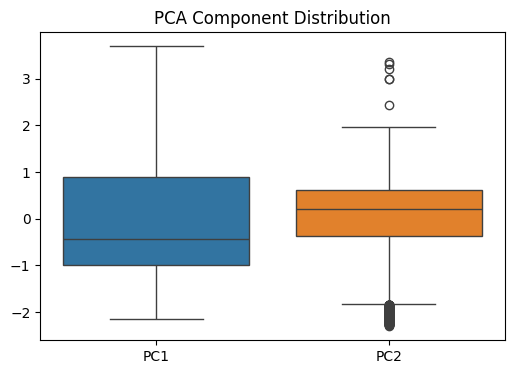

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
pca = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)
plt.figure(figsize=(6,4))
sns.boxplot(data=pca)
plt.title("PCA Component Distribution")
plt.show()